In [17]:
import sys
sys.path.insert(0, '/global/homes/m/mpowell/repos/microhh/python')

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from microhh.python.plot_microhh_utils import get_local_start

# RUNDIR  = '/pscratch/sd/m/mpowell/CASS_LES/debug/base/2stream/rep_01'
# RUNDIR2 = '/pscratch/sd/m/mpowell/CASS_LES/debug/base/raytracer/rep_01'

# RUNDIR  = '/pscratch/sd/m/mpowell/CASS_LES/debug/cs_veg/cs_veg_42000/2stream/rep_01'
# RUNDIR2 = '/pscratch/sd/m/mpowell/CASS_LES/debug/cs_veg/cs_veg_42000/raytracer/rep_01'

# RUNDIR  = '/pscratch/sd/m/mpowell/CASS_LES/debug/no_aerosols/2stream/rep_01'
# RUNDIR2 = '/pscratch/sd/m/mpowell/CASS_LES/debug/no_aerosols/raytracer/rep_01'

RUNDIR  = '/pscratch/sd/m/mpowell/CASS_LES/debug/soil_moisture/theta_0p4/2stream/rep_01'
RUNDIR2 = '/pscratch/sd/m/mpowell/CASS_LES/debug/soil_moisture/theta_0p4/raytracer/rep_01'

def load_run(path):
    ds     = nc.Dataset(f'{path}/cass.default.0000000.nc')
    t_sec  = ds.variables['time'][:]
    zs     = ds.variables['zs'][:]
    ls     = ds.groups['land_surface']
    rad    = ds.groups['radiation']
    thermo = ds.groups['thermo']

    start   = get_local_start(path)
    t_local = pd.to_datetime([start + pd.Timedelta(seconds=float(s)) for s in t_sec])

    out = dict(
        t_local   = t_local,
        zs        = zs,
        theta     = ls.variables['theta'][:],
        H         = ls.variables['H'][:],
        LE        = ls.variables['LE'][:],
        G         = ls.variables['G'][:],
        S         = ls.variables['S'][:],
        sw_dn     = rad.variables['sw_flux_dn'][:, 0],
        sw_up     = rad.variables['sw_flux_up'][:, 0],
        lw_dn     = rad.variables['lw_flux_dn'][:, 0],
        lw_up     = rad.variables['lw_flux_up'][:, 0],
        qlqi_path = thermo.variables['qlqi_path'][:],
        ql_cover  = thermo.variables['ql_cover'][:],
        qlqi_cover= thermo.variables['qlqi_cover'][:],
    )
    out['Rnet'] = (out['sw_dn'] - out['sw_up']) + (out['lw_dn'] - out['lw_up'])
    return out

r1 = load_run(RUNDIR)   # 2stream
r2 = load_run(RUNDIR2)  # raytracer

RUNS   = [('2stream',   r1), ('raytracer', r2)]
RUN_LS = {'2stream': '-', 'raytracer': '--'}

for label, r in RUNS:
    print(f'{label}: {r["t_local"][0]} → {r["t_local"][-1]}')

2stream: 2005-07-24 05:30:00-05:00 → 2005-07-24 19:20:00-05:00
raytracer: 2005-07-24 05:30:00-05:00 → 2005-07-24 16:59:59.999999999-05:00


## 1. Theta evolution

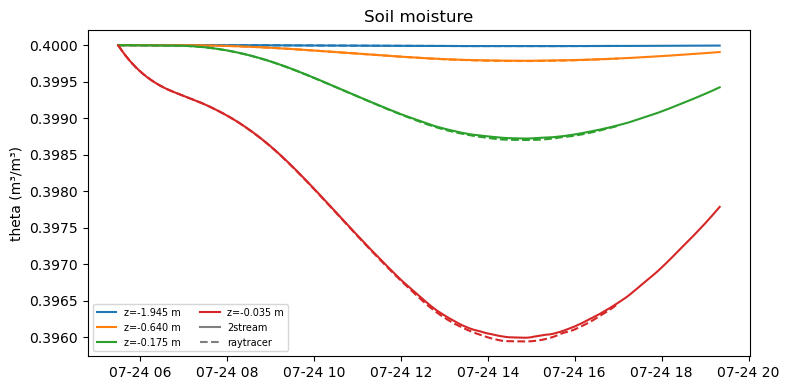

In [18]:
LAYER_COLORS = ['C0', 'C1', 'C2', 'C3']

fig, ax = plt.subplots(figsize=(8, 4))
for label, r in RUNS:
    for i, (color, z) in enumerate(zip(LAYER_COLORS, r['zs'])):
        ax.plot(r['t_local'], r['theta'][:, i], color=color, ls=RUN_LS[label])

from matplotlib.lines import Line2D
handles  = [Line2D([0], [0], color=c, ls='-', label=f'z={z:.3f} m')
            for c, z in zip(LAYER_COLORS, r['zs'])]
handles += [Line2D([0], [0], color='gray', ls=ls, label=lbl)
            for lbl, ls in RUN_LS.items()]
ax.legend(handles=handles, fontsize=7, ncol=2)
ax.set_ylabel('theta (m³/m³)')
ax.set_title('Soil moisture')
# ax.set_ylim(0.35, 0.45)
plt.tight_layout()
plt.show()

## 2. Surface energy balance

2stream  peak |resid|=6.41  daytime mean |resid|=0.24 W/m²
raytracer  peak |resid|=14.94  daytime mean |resid|=3.94 W/m²


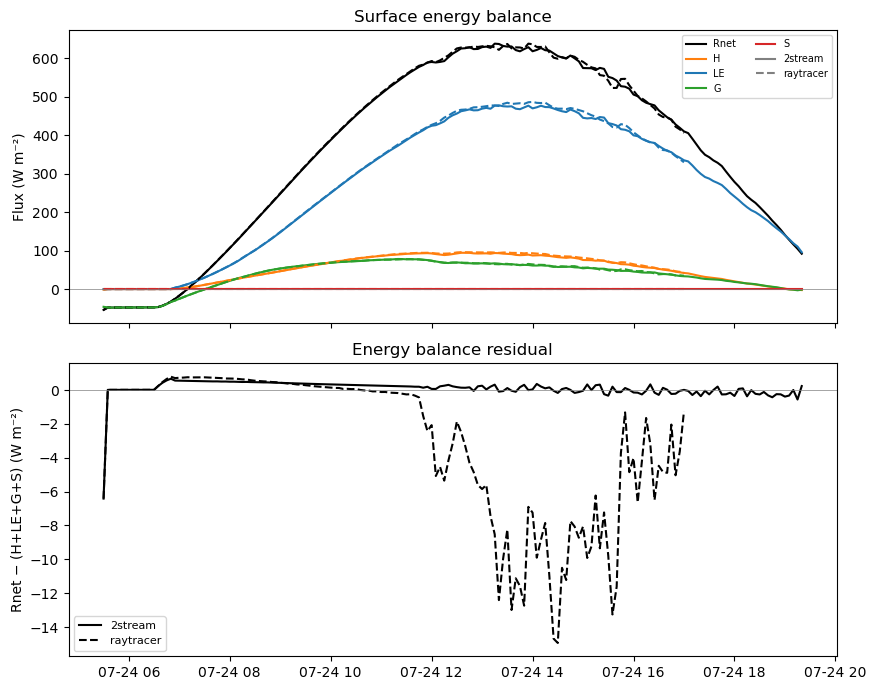

In [19]:
FLUX_COLORS = {'Rnet': 'k', 'H': 'C1', 'LE': 'C0', 'G': 'C2', 'S': 'C3'}

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax = axes[0]
for label, r in RUNS:
    for flux, color in FLUX_COLORS.items():
        ax.plot(r['t_local'], r[flux], color=color, ls=RUN_LS[label])

from matplotlib.lines import Line2D
handles  = [Line2D([0], [0], color=c, ls='-', label=f) for f, c in FLUX_COLORS.items()]
handles += [Line2D([0], [0], color='gray', ls=ls, label=lbl) for lbl, ls in RUN_LS.items()]
ax.legend(handles=handles, fontsize=7, ncol=2)
ax.set_ylabel('Flux (W m⁻²)')
ax.set_title('Surface energy balance')
ax.axhline(0, color='gray', lw=0.5)

ax = axes[1]
for label, r in RUNS:
    SEB   = r['H'] + r['LE'] + r['G'] + r['S']
    resid = r['Rnet'] - SEB
    ax.plot(r['t_local'], resid, ls=RUN_LS[label], color='k', label=label)
    print(f"{label}  peak |resid|={np.abs(resid).max():.2f}  "
          f"daytime mean |resid|={np.abs(resid[r['Rnet']>50]).mean():.2f} W/m²")
ax.axhline(0, color='gray', lw=0.5)
ax.set_ylabel('Rnet − (H+LE+G+S) (W m⁻²)')
ax.set_title('Energy balance residual')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Bowen ratio and surface fluxes

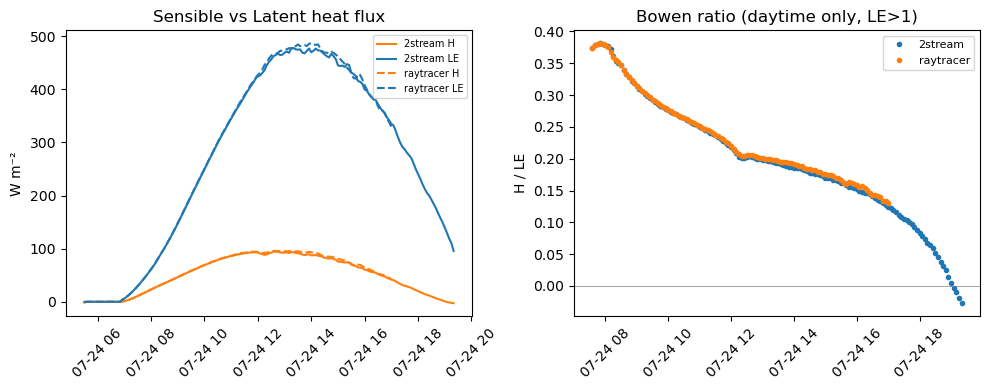

2stream  LE=[-0.16, 477.85]  H=[-2.6, 94.4] W/m²
raytracer  LE=[-0.16, 486.68]  H=[-1.4, 95.9] W/m²


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
for label, r in RUNS:
    ax.plot(r['t_local'], r['H'],  color='C1', ls=RUN_LS[label], label=f'{label} H')
    ax.plot(r['t_local'], r['LE'], color='C0', ls=RUN_LS[label], label=f'{label} LE')
ax.set_ylabel('W m⁻²')
ax.set_title('Sensible vs Latent heat flux')
ax.legend(fontsize=7)
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
for label, r in RUNS:
    daytime = r['Rnet'] > 50
    with np.errstate(divide='ignore', invalid='ignore'):
        BR = np.where(r['LE'] > 1.0, r['H'] / r['LE'], np.nan)
    ax.plot(r['t_local'][daytime], BR[daytime], 'o', ms=3, label=label)
ax.axhline(0, color='gray', lw=0.5)
ax.set_ylabel('H / LE')
ax.set_title('Bowen ratio (daytime only, LE>1)')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

for label, r in RUNS:
    print(f"{label}  LE=[{r['LE'].min():.2f}, {r['LE'].max():.2f}]  "
          f"H=[{r['H'].min():.1f}, {r['H'].max():.1f}] W/m²")

## 4. Cloud development (LWP and cloud fraction)

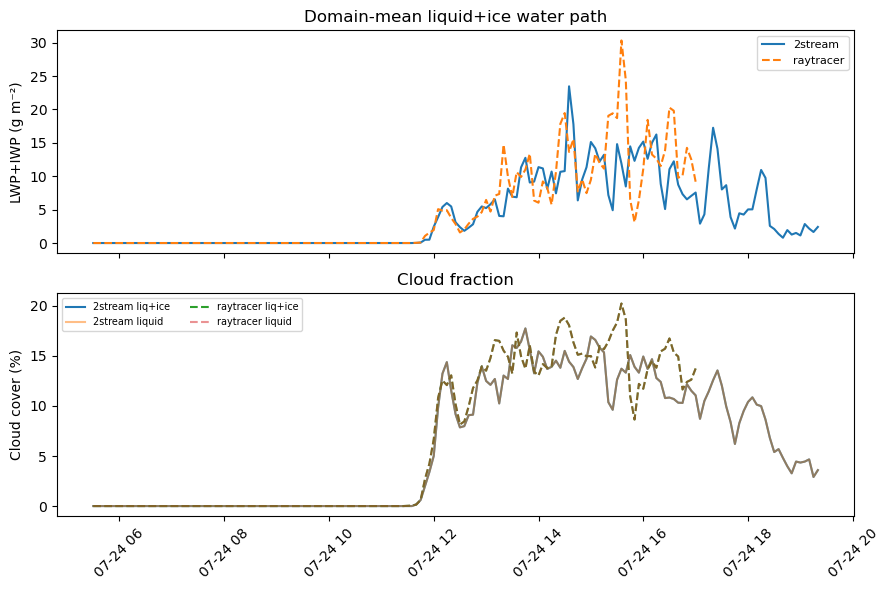

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax = axes[0]
for label, r in RUNS:
    ax.plot(r['t_local'], r['qlqi_path'] * 1e3, ls=RUN_LS[label], label=label)
ax.set_ylabel('LWP+IWP (g m⁻²)')
ax.set_title('Domain-mean liquid+ice water path')
ax.legend(fontsize=8)

ax = axes[1]
for label, r in RUNS:
    ax.plot(r['t_local'], r['qlqi_cover'] * 100, ls=RUN_LS[label], label=f'{label} liq+ice')
    ax.plot(r['t_local'], r['ql_cover']  * 100, ls=RUN_LS[label], alpha=0.5, label=f'{label} liquid')
ax.set_ylabel('Cloud cover (%)')
ax.set_title('Cloud fraction')
ax.legend(fontsize=7, ncol=2)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [3]:
import xarray as xr

ds_b = xr.open_dataset("/pscratch/sd/m/mpowell/CASS_LES/debug/base/2stream/rep_01/thl_fluxbot.xy.nc", decode_times = False) 
ds_b_rt = xr.open_dataset("/pscratch/sd/m/mpowell/CASS_LES/debug/base/raytracer/rep_01/thl_fluxbot.xy.nc", decode_times = False) 

ds = xr.open_dataset("/pscratch/sd/m/mpowell/CASS_LES/debug/no_aerosols/2stream/rep_01/thl_fluxbot.xy.nc", decode_times = False) 
ds_rt = xr.open_dataset("/pscratch/sd/m/mpowell/CASS_LES/debug/no_aerosols/raytracer/rep_01/thl_fluxbot.xy.nc", decode_times = False) 

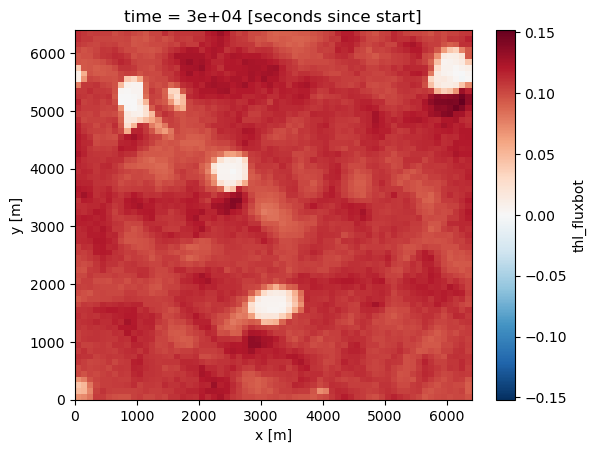

In [4]:
ds_b_rt.thl_fluxbot.isel(time = 500).plot()

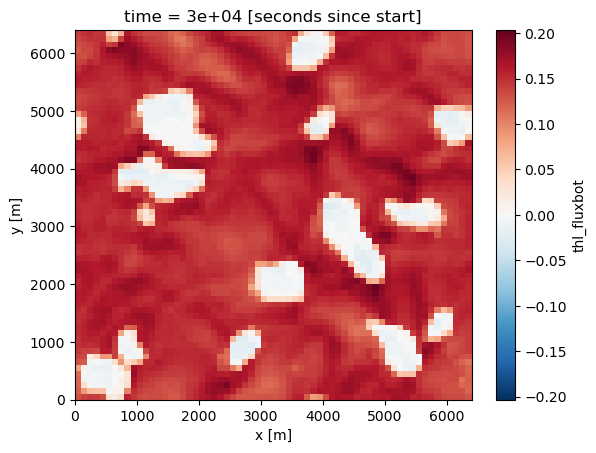

In [5]:
ds_rt.thl_fluxbot.isel(time = 500).plot()

In [8]:
ds_in = xr.open_dataset("/pscratch/sd/m/mpowell/CASS_LES/debug/base/raytracer/rep_01/cass_input.nc", group = 'init')
# ds_in_tij = xr.open_dataset("/pscratch/sd/m/mpowell/inputfiles_cumulus_cases_2/20160815_t03/cabauw_input.nc", group = 'init')

In [9]:
ds_in

<xarray.Dataset> Size: 39kB
Dimensions:   (z: 256)
Coordinates:
  * z         (z) float64 2kB 12.5 37.5 62.5 ... 6.338e+03 6.362e+03 6.388e+03
Data variables: (12/23)
    thl       (z) float64 2kB ...
    qt        (z) float64 2kB ...
    u         (z) float64 2kB ...
    v         (z) float64 2kB ...
    nudgefac  (z) float64 2kB ...
    aermr01   (z) float64 2kB ...
    ...        ...
    o3        (z) float64 2kB ...
    co2       float64 8B ...
    ch4       float64 8B ...
    n2o       float64 8B ...
    n2        float64 8B ...
    o2        float64 8B ...

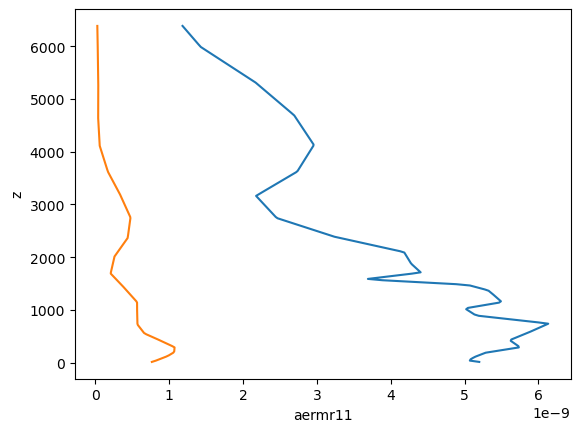

In [3]:
ds_in.aermr11.plot(y = 'z')
ds_in_tij.aermr11.plot(y = 'z')

In [4]:
ds_raw = xr.open_dataset("/pscratch/sd/m/mpowell/LS2D_CAMS/cass/2009/06/21/eac4_ml.nc")
ds_raw

<xarray.Dataset> Size: 2GB
Dimensions:      (valid_time: 8, model_level: 60, latitude: 16, longitude: 2880)
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 64B 2009-06-21 ... 2009-06-21T21...
  * model_level  (model_level) float64 480B 1.0 2.0 3.0 4.0 ... 58.0 59.0 60.0
  * longitude    (longitude) float64 23kB -455.5 -455.2 -455.0 ... 264.0 264.2
  * latitude     (latitude) float64 128B 34.75 35.0 35.25 ... 38.0 38.25 38.5
Data variables: (12/13)
    aermr04      (valid_time, model_level, latitude, longitude) float64 177MB ...
    aermr05      (valid_time, model_level, latitude, longitude) float64 177MB ...
    aermr06      (valid_time, model_level, latitude, longitude) float64 177MB ...
    aermr09      (valid_time, model_level, latitude, longitude) float64 177MB ...
    aermr07      (valid_time, model_level, latitude, longitude) float64 177MB ...
    aermr10      (valid_time, model_level, latitude, longitude) float64 177MB ...
    ...           ...
    aermr01      (valid_time, model_level, latitude, longitude) float64 177MB ...
    aermr02      (valid_time, model_level, latitude, longitude) float64 177MB ...
    aermr03      (valid_time, model_level, latitude, longitude) float64 177MB ...
    aermr11      (valid_time, model_level, latitude, longitude) float64 177MB ...
    q            (valid_time, model_level, latitude, longitude) float64 177MB ...
    t            (valid_time, model_level, latitude, longitude) float64 177MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-23T23:23 GRIB to CDM+CF via cfgrib-0.9.1...